In [ ]:
%pip install -q \
  transformers==4.51.3 accelerate bitsandbytes sentencepiece \
  bert-score rouge-score nltk pandas numpy matplotlib seaborn \
  tqdm requests groq pydantic datasets huggingface_hub torch

import nltk
nltk.download('punkt',   quiet=True)
nltk.download('wordnet', quiet=True)
print("✅ Libraries ready")

In [ ]:
import os, json, random, time as _time, threading

#Lấy key
HF_TOKEN     = os.environ.get("HF_TOKEN", "")
GROQ_API_KEY = os.environ.get("GROQ_API_KEY", "")

MEDGEMMA_MODEL_ID        = "google/medgemma-1.5-4b-it"
EVAL_FAST_MODE           = True
GEN_MAX_TOKENS           = 512
MAX_SC_SAMPLES           = 30
MAX_CB_SAMPLES           = 30
MAX_EVAL_ITEMS_PER_MODEL = 30
CACHE_PATH               = "./evaluation_cache.json"
ENABLE_RESPONSE_CACHE    = True
GROQ_CONCURRENCY         = 1
MEDGEMMA_CONCURRENCY     = 1

In [ ]:
if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH, "r", encoding="utf-8") as _f:
        _cache = json.load(_f)
    _stale = [k for k, v in _cache.items()
              if isinstance(v, dict) and str(v.get("text", "")).startswith("[ERROR]")]
    for k in _stale:
        del _cache[k]
    if _stale:
        with open(CACHE_PATH, "w", encoding="utf-8") as _f:
            json.dump(_cache, _f, ensure_ascii=False, indent=2)
        print(f"🗑️  Removed {len(_stale)} stale error entries from cache.")
    else:
        print("✅ Cache clean.")
else:
    print("ℹ️  No cache found — starting fresh.")


[1/4] LOAD ─────────────────────────────────
  ✓ Loaded  : 12,060 rows | columns: ['Disease', 'Question']
  dtypes    :
Disease     object
Question    object

[2/4] CLEAN ────────────────────────────────
  Removed empty rows        : 0
  Removed exact duplicates  : 145
  Near-duplicate symptom texts (cross-disease): 848
  Final clean size          : 11,915 rows

[3/4] PROCESS ──────────────────────────────
  Features added: q_char_len, q_word_len, has_template, symptom_count, question_type, disease_freq

[4/4] EVALUATE ─────────────────────────────
  [4.1] Class distribution


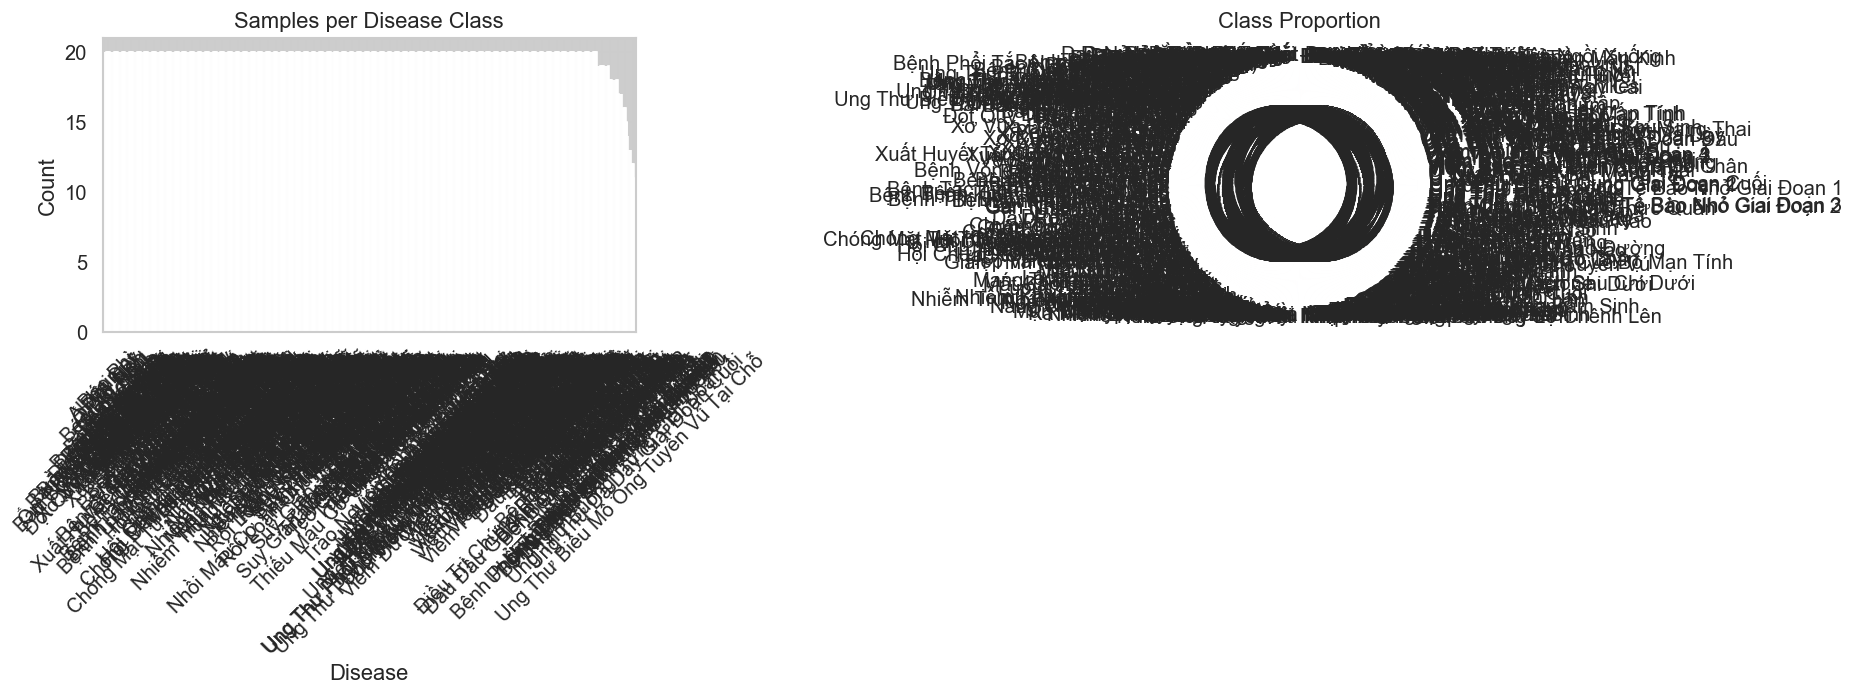

  [4.2] Text length analysis


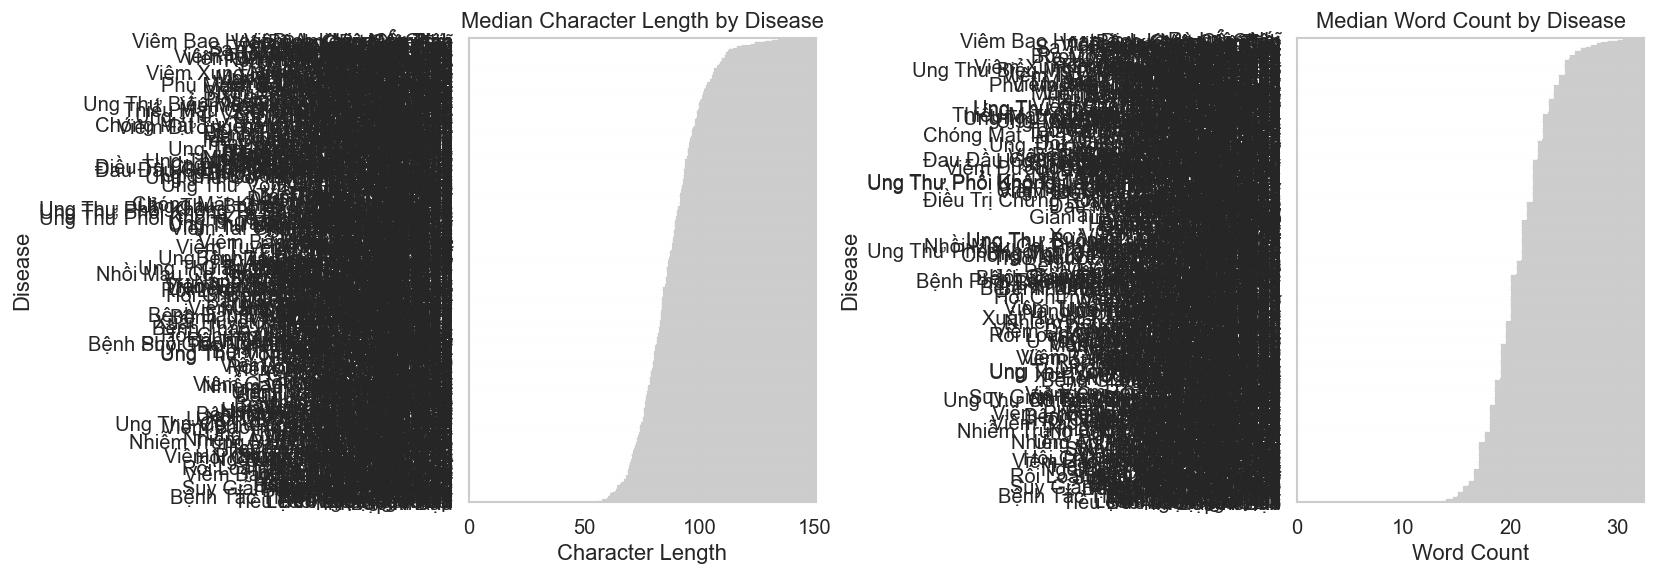

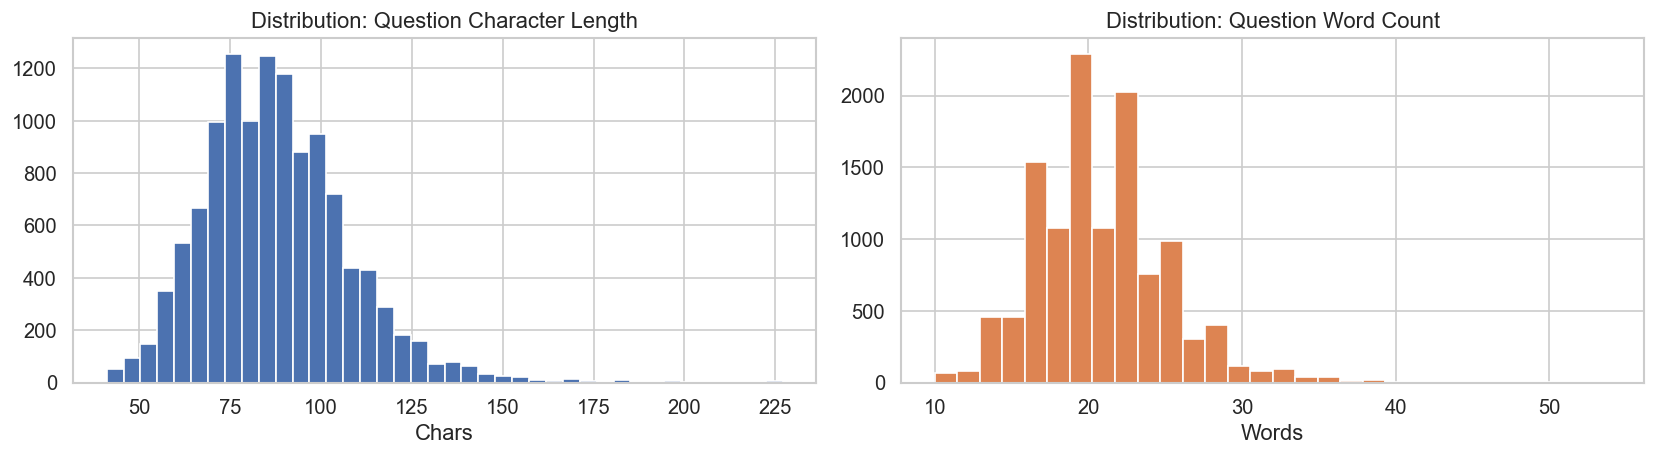

  [4.3] Template consistency


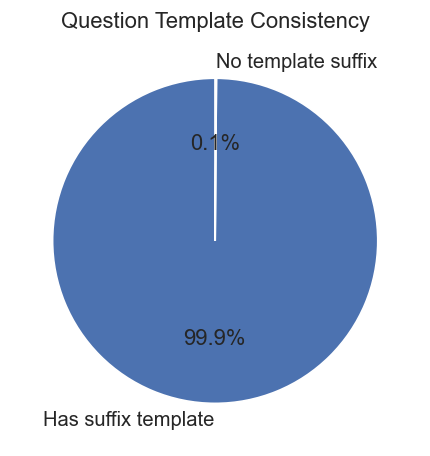

  [4.4] Symptom count per question


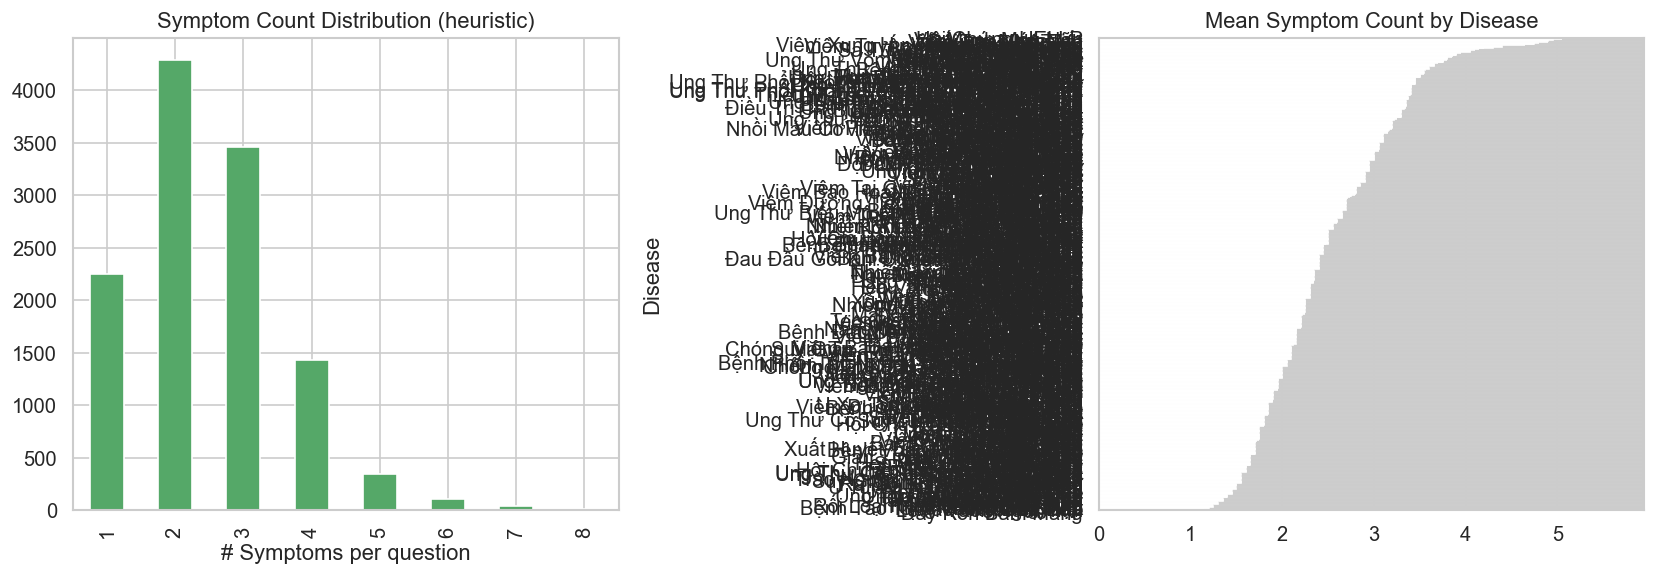

  [4.5] Duplicate analysis


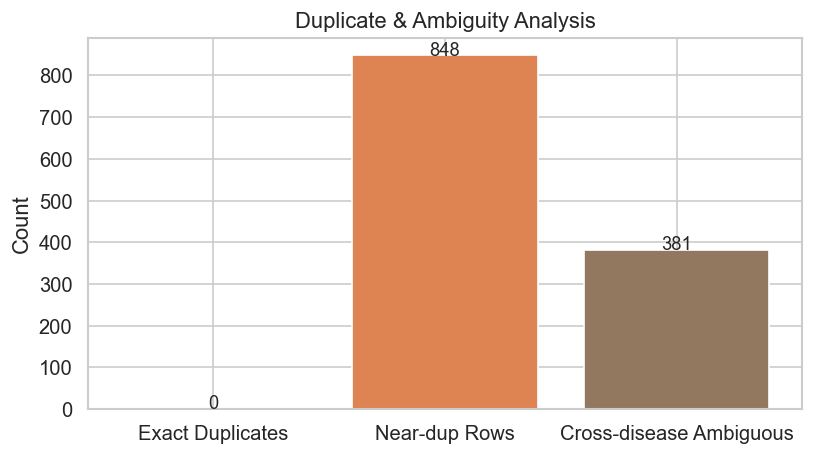

  [4.6] Question type tagging


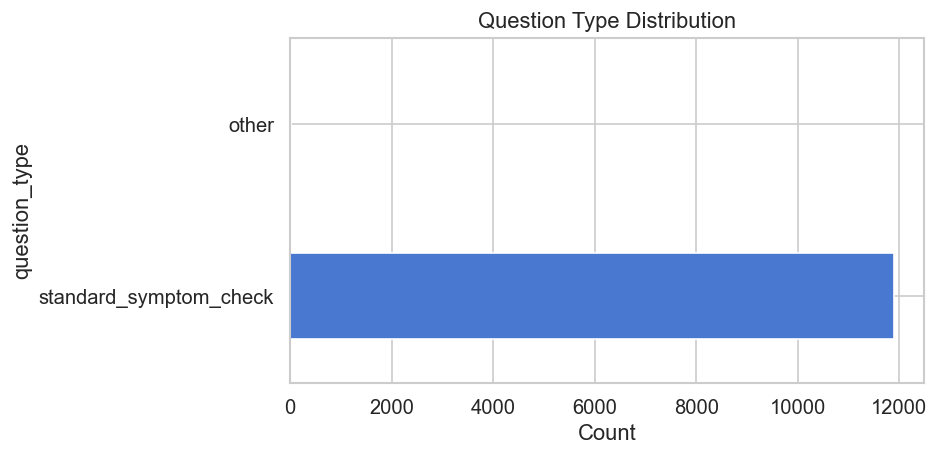

  [4.7] Vocabulary richness (unique tokens per disease)


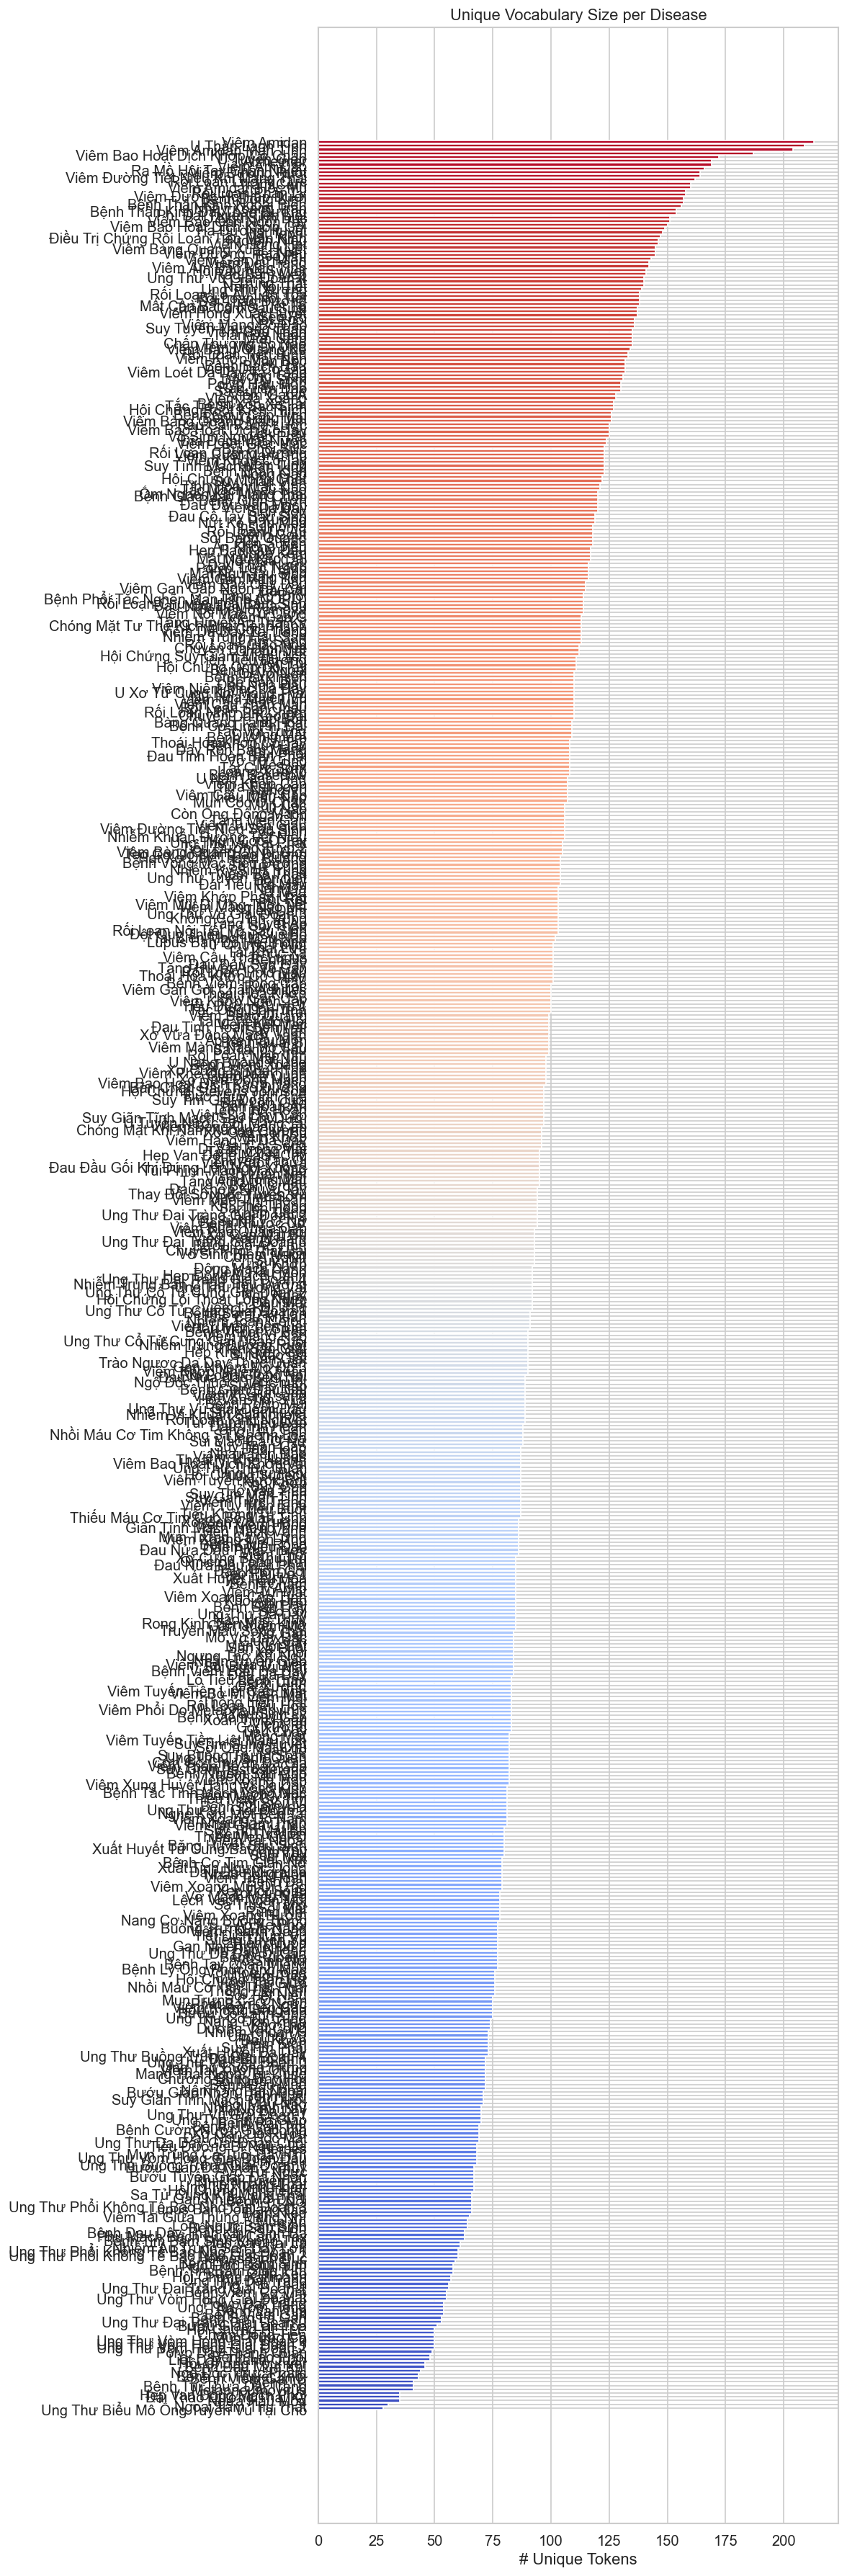

  [4.8] MedGemma readiness assessment


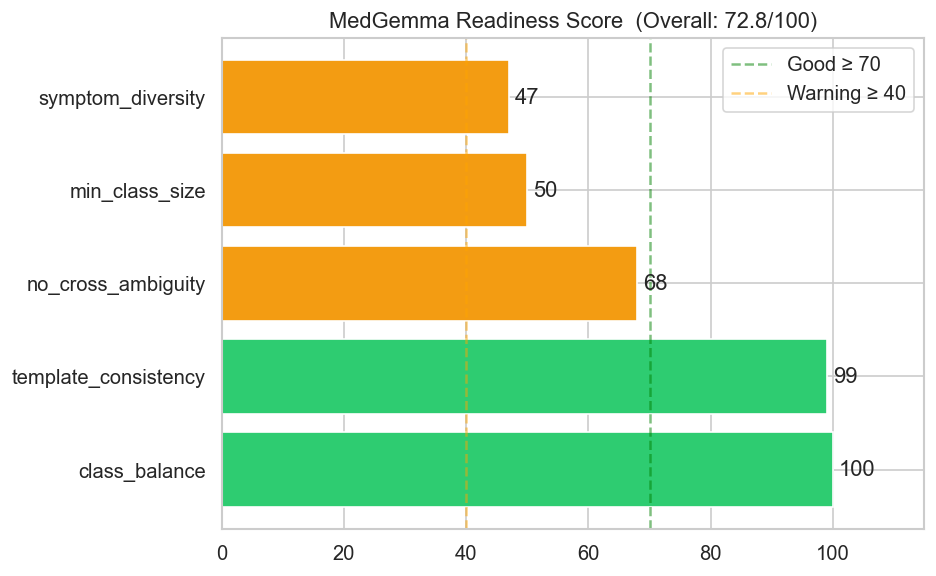


[5/5] EXPORT ───────────────────────────────
  ✓ Report saved → vimedical_report.xlsx
  ✓ Figures saved → vimedical_figures/

  VIMEDICAL DATASET QUALITY SUMMARY
  Total samples           : 11,915
  Disease classes         : 603
  Samples/class  (min/max): 10 / 20
  Imbalance ratio         : 2.0x
  Gini balance score      : 0.9983  (1.0 = perfect)
  Exact duplicates        : 0
  Cross-disease ambiguous : 381
  Template consistency    : 99.9%
  Mean symptoms/question  : 2.48
  Mean vocab/disease      : 95.9

  ★ MedGemma Readiness    : 72.8 / 100


In [5]:
"""
ViMedical Disease Dataset — Load → Clean → Process → Evaluate Pipeline
=======================================================================
Mục tiêu: Đánh giá chất lượng dataset trước khi dùng để benchmark MedGemma.

Yêu cầu:
    pip install datasets pandas numpy matplotlib seaborn scikit-learn langdetect tqdm openpyxl

Chạy:
    python vimedical_evaluation_pipeline.py
    → Sinh ra: vimedical_report.xlsx  +  vimedical_figures/  (thư mục ảnh)
"""

# ─────────────────────────────────────────────
# 0. IMPORTS
# ─────────────────────────────────────────────
import re
import os
import warnings
import unicodedata
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm import tqdm

%matplotlib inline
plt.rcParams.update({
    "figure.figsize": (12, 5),   # default size
    "figure.dpi": 120,            # sắc nét hơn
    "axes.spines.top": False,
    "axes.spines.right": False,
})
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
FIG_DIR = Path("vimedical_figures")
FIG_DIR.mkdir(exist_ok=True)

# ─────────────────────────────────────────────
# 1. LOAD
# ─────────────────────────────────────────────
def load_data() -> pd.DataFrame:
    print("\n[1/4] LOAD ─────────────────────────────────")
    from datasets import load_dataset
    raw = load_dataset("PB3002/ViMedical_Disease", split="train").to_pandas()
    print(f"  ✓ Loaded  : {len(raw):,} rows | columns: {list(raw.columns)}")
    print(f"  dtypes    :\n{raw.dtypes.to_string()}")
    return raw


# ─────────────────────────────────────────────
# 2. CLEAN
# ─────────────────────────────────────────────
COMMON_TEMPLATES = [
    r"tôi có thể đang bị bệnh gì\??",
    r"tôi có thể đang mắc bệnh gì\??",
    r"tôi bị bệnh gì\??",
]
TEMPLATE_RE = re.compile("|".join(COMMON_TEMPLATES), re.IGNORECASE)

def normalize_text(s: str) -> str:
    """NFD → NFC, strip dư whitespace."""
    s = unicodedata.normalize("NFC", str(s))
    s = re.sub(r"\s+", " ", s).strip()
    return s

def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    print("\n[2/4] CLEAN ────────────────────────────────")
    df = df.copy()

    # 2.1 — normalize whitespace & unicode
    for col in ["Disease", "Question"]:
        df[col] = df[col].fillna("").apply(normalize_text)

    n_before = len(df)

    # 2.2 — drop fully empty rows
    df = df[(df["Disease"] != "") & (df["Question"] != "")]
    print(f"  Removed empty rows        : {n_before - len(df)}")

    # 2.3 — exact duplicates (Disease + Question)
    n_dup = df.duplicated(subset=["Disease", "Question"]).sum()
    df = df.drop_duplicates(subset=["Disease", "Question"]).reset_index(drop=True)
    print(f"  Removed exact duplicates  : {n_dup}")

    # 2.4 — strip trailing template phrase to isolate symptom body
    df["Question_clean"] = df["Question"].apply(
        lambda q: TEMPLATE_RE.sub("", q).strip(" .,")
    )

    # 2.5 — near-duplicate detection (same symptom body, different disease)
    n_near = df.duplicated(subset="Question_clean", keep=False).sum()
    print(f"  Near-duplicate symptom texts (cross-disease): {n_near}")

    print(f"  Final clean size          : {len(df):,} rows")
    return df


# ─────────────────────────────────────────────
# 3. PROCESS — Feature engineering
# ─────────────────────────────────────────────
def process_data(df: pd.DataFrame) -> pd.DataFrame:
    print("\n[3/4] PROCESS ──────────────────────────────")
    df = df.copy()

    # 3.1 — text lengths
    df["q_char_len"]  = df["Question"].str.len()
    df["q_word_len"]  = df["Question"].str.split().str.len()
    df["q_clean_len"] = df["Question_clean"].str.len()

    # 3.2 — has template suffix?
    df["has_template"] = df["Question"].str.contains(
        TEMPLATE_RE, regex=True
    )

    # 3.3 — symptom count heuristic
    SYMPTOM_DELIMITERS = re.compile(r"[,;]|\bvà\b|\bhoặc\b|\bnhư\b|\bnhư là\b")
    df["symptom_count"] = df["Question_clean"].apply(
        lambda q: max(1, len(SYMPTOM_DELIMITERS.split(q)))
    )

    # 3.4 — question type tag
    def tag_question(q: str) -> str:
        q_l = q.lower()
        if "tôi có thể đang bị" in q_l or "tôi có thể đang mắc" in q_l:
            return "standard_symptom_check"
        if "triệu chứng" in q_l:
            return "symptom_mention"
        if "cảm thấy" in q_l:
            return "subjective_feeling"
        return "other"

    df["question_type"] = df["Question"].apply(tag_question)

    # 3.5 — disease label stats
    disease_counts = df["Disease"].value_counts()
    df["disease_freq"] = df["Disease"].map(disease_counts)

    print(f"  Features added: q_char_len, q_word_len, has_template, "
          f"symptom_count, question_type, disease_freq")
    return df


# ─────────────────────────────────────────────
# 4. EVALUATE — Quality report
# ─────────────────────────────────────────────
# Thay hàm plot_save cũ bằng hàm này
def plot_show(fig, name: str = ""):
    plt.tight_layout()
    plt.show()
    plt.close(fig)


def evaluate_data(df: pd.DataFrame) -> dict:
    print("\n[4/4] EVALUATE ─────────────────────────────")
    report = {}

    # ── 4.1 Class Distribution ──────────────────
    print("  [4.1] Class distribution")
    disease_vc = df["Disease"].value_counts()
    report["n_classes"]        = len(disease_vc)
    report["n_samples"]        = len(df)
    report["min_per_class"]    = int(disease_vc.min())
    report["max_per_class"]    = int(disease_vc.max())
    report["mean_per_class"]   = round(disease_vc.mean(), 2)
    report["median_per_class"] = round(disease_vc.median(), 2)
    report["std_per_class"]    = round(disease_vc.std(), 2)

    # Imbalance ratio
    report["imbalance_ratio"]  = round(disease_vc.max() / disease_vc.min(), 2)

    # Gini impurity proxy
    props = disease_vc / disease_vc.sum()
    report["gini_class_balance"] = round(1 - (props**2).sum(), 4)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    disease_vc.plot(kind="bar", ax=axes[0], color=sns.color_palette("muted"))
    axes[0].set_title("Samples per Disease Class")
    axes[0].set_xlabel("Disease")
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis="x", rotation=45)

    axes[1].pie(disease_vc.values,
                labels=disease_vc.index,
                autopct="%1.1f%%",
                startangle=140,
                colors=sns.color_palette("pastel"))
    axes[1].set_title("Class Proportion")

    
    plot_show(fig, "4.1_class_distribution.png")

    # ── 4.2 Text Length Distribution ───────────────
    print("  [4.2] Text length analysis")
    for col, label in [("q_char_len", "Chars"), ("q_word_len", "Words")]:
        report[f"q_{label.lower()}_mean"]   = round(df[col].mean(), 2)
        report[f"q_{label.lower()}_std"]    = round(df[col].std(), 2)
        report[f"q_{label.lower()}_min"]    = int(df[col].min())
        report[f"q_{label.lower()}_max"]    = int(df[col].max())
        report[f"q_{label.lower()}_p5"]     = round(df[col].quantile(0.05), 1)
        report[f"q_{label.lower()}_p95"]    = round(df[col].quantile(0.95), 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, col, label in zip(axes,
                               ["q_char_len", "q_word_len"],
                               ["Character Length", "Word Count"]):
        df.groupby("Disease")[col].median().sort_values().plot(
            kind="barh", ax=ax, color=sns.color_palette("muted")[2]
        )
        ax.set_title(f"Median {label} by Disease")
        ax.set_xlabel(label)
    plot_show(fig, "4.2_text_length_by_disease.png")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    df["q_char_len"].hist(bins=40, ax=axes[0], color="#4C72B0", edgecolor="white")
    axes[0].set_title("Distribution: Question Character Length")
    axes[0].set_xlabel("Chars")
    df["q_word_len"].hist(bins=30, ax=axes[1], color="#DD8452", edgecolor="white")
    axes[1].set_title("Distribution: Question Word Count")
    axes[1].set_xlabel("Words")
    plot_show(fig, "4.2_text_length_histogram.png")

    # ── 4.3 Template / Format Consistency ─────────
    print("  [4.3] Template consistency")
    template_rate = df["has_template"].mean()
    report["template_rate"] = round(template_rate, 4)
    report["no_template_count"] = int((~df["has_template"]).sum())

    fig, ax = plt.subplots(figsize=(6, 4))
    vals = [df["has_template"].sum(), (~df["has_template"]).sum()]
    ax.pie(vals,
           labels=["Has suffix template", "No template suffix"],
           autopct="%1.1f%%",
           colors=["#4C72B0", "#DD8452"],
           startangle=90)
    ax.set_title("Question Template Consistency")
    plot_show(fig, "4.3_template_consistency.png")

    # ── 4.4 Symptom Count Distribution ───────────
    print("  [4.4] Symptom count per question")
    report["symptom_count_mean"]   = round(df["symptom_count"].mean(), 2)
    report["symptom_count_median"] = int(df["symptom_count"].median())
    report["symptom_count_max"]    = int(df["symptom_count"].max())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    df["symptom_count"].value_counts().sort_index().plot(
        kind="bar", ax=axes[0], color="#55A868", edgecolor="white"
    )
    axes[0].set_title("Symptom Count Distribution (heuristic)")
    axes[0].set_xlabel("# Symptoms per question")

    df.groupby("Disease")["symptom_count"].mean().sort_values().plot(
        kind="barh", ax=axes[1], color="#55A868"
    )
    axes[1].set_title("Mean Symptom Count by Disease")
    plot_show(fig, "4.4_symptom_count.png")

    # ── 4.5 Duplicate / Near-duplicate analysis ───
    print("  [4.5] Duplicate analysis")
    exact_dup = df.duplicated(subset=["Disease", "Question"]).sum()
    near_dup  = df.duplicated(subset="Question_clean", keep=False).sum()
    cross_dup = df[df.duplicated(subset="Question_clean", keep=False)] \
                  .groupby("Question_clean")["Disease"].nunique()
    cross_amb = (cross_dup > 1).sum()

    report["exact_duplicates"]           = int(exact_dup)
    report["near_duplicates_total"]      = int(near_dup)
    report["cross_disease_ambiguous"]    = int(cross_amb)

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(
        ["Exact Duplicates", "Near-dup Rows", "Cross-disease Ambiguous"],
        [exact_dup, near_dup, cross_amb],
        color=["#C44E52", "#DD8452", "#937860"],
        edgecolor="white"
    )
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2,
                b.get_height() + 0.5,
                str(int(b.get_height())), ha="center", fontsize=11)
    ax.set_title("Duplicate & Ambiguity Analysis")
    ax.set_ylabel("Count")
    plot_show(fig, "4.5_duplicates.png")

    # ── 4.6 Question Type Breakdown ───────────────
    print("  [4.6] Question type tagging")
    qt = df["question_type"].value_counts()
    report["question_types"] = qt.to_dict()

    fig, ax = plt.subplots(figsize=(8, 4))
    qt.plot(kind="barh", ax=ax, color=sns.color_palette("muted"))
    ax.set_title("Question Type Distribution")
    ax.set_xlabel("Count")
    plot_show(fig, "4.6_question_types.png")

    # ── 4.7 Vocabulary richness per disease ───────
    print("  [4.7] Vocabulary richness (unique tokens per disease)")
    def vocab_size(texts):
        tokens = " ".join(texts).lower().split()
        return len(set(tokens))

    vocab_df = df.groupby("Disease")["Question_clean"].apply(vocab_size).reset_index()
    vocab_df.columns = ["Disease", "VocabSize"]
    vocab_df = vocab_df.sort_values("VocabSize", ascending=True)
    report["mean_vocab_per_disease"] = round(vocab_df["VocabSize"].mean(), 1)

    fig, ax = plt.subplots(figsize=(10, 30))
    ax.barh(vocab_df["Disease"], vocab_df["VocabSize"],
            color=sns.color_palette("coolwarm", len(vocab_df)))
    ax.set_title("Unique Vocabulary Size per Disease")
    ax.set_xlabel("# Unique Tokens")
    plot_show(fig, "4.7_vocab_richness.png")

    # ── 4.8 MedGemma Readiness Score ──────────────
    print("  [4.8] MedGemma readiness assessment")
    # Heuristic scoring rubric (0–100)
    scores = {}
    scores["class_balance"]      = min(100, int(100 / report["imbalance_ratio"] * 10))
    scores["template_consistency"] = int(report["template_rate"] * 100)
    scores["no_cross_ambiguity"]  = int(max(0, 100 - cross_amb / len(df) * 1000))
    scores["min_class_size"]      = min(100, report["min_per_class"] * 5)
    scores["symptom_diversity"]   = min(100, int(report["mean_vocab_per_disease"] / 2))

    overall = round(np.mean(list(scores.values())), 1)
    report["medgemma_readiness_score"] = overall
    report["readiness_breakdown"] = scores

    fig, ax = plt.subplots(figsize=(8, 5))
    cats = list(scores.keys())
    vals = list(scores.values())
    colors = ["#2ecc71" if v >= 70 else "#f39c12" if v >= 40 else "#e74c3c" for v in vals]
    bars = ax.barh(cats, vals, color=colors, edgecolor="white")
    ax.axvline(70, color="green", linestyle="--", alpha=0.5, label="Good ≥ 70")
    ax.axvline(40, color="orange", linestyle="--", alpha=0.5, label="Warning ≥ 40")
    for b, v in zip(bars, vals):
        ax.text(v + 1, b.get_y() + b.get_height()/2, str(v), va="center")
    ax.set_xlim(0, 115)
    ax.set_title(f"MedGemma Readiness Score  (Overall: {overall}/100)")
    ax.legend()
    plot_show(fig, "4.8_medgemma_readiness.png")

    return report


# ─────────────────────────────────────────────
# 5. EXPORT — Excel report
# ─────────────────────────────────────────────
def export_report(df: pd.DataFrame, report: dict):
    print("\n[5/5] EXPORT ───────────────────────────────")
    path = "vimedical_report.xlsx"
    with pd.ExcelWriter(path, engine="openpyxl") as writer:

        # Sheet 1: Clean data
        df.to_excel(writer, sheet_name="CleanData", index=False)

        # Sheet 2: Per-disease summary
        summary = df.groupby("Disease").agg(
            n_samples       = ("Question", "count"),
            mean_chars      = ("q_char_len", "mean"),
            mean_words      = ("q_word_len", "mean"),
            mean_symptoms   = ("symptom_count", "mean"),
            template_rate   = ("has_template", "mean"),
        ).round(2).reset_index()
        summary.to_excel(writer, sheet_name="DiseaseStats", index=False)

        # Sheet 3: Quality report
        flat = {}
        for k, v in report.items():
            if isinstance(v, dict):
                for k2, v2 in v.items():
                    flat[f"{k}.{k2}"] = v2
            else:
                flat[k] = v
        pd.DataFrame(flat.items(), columns=["Metric", "Value"]).to_excel(
            writer, sheet_name="QualityReport", index=False
        )

        # Sheet 4: Near-duplicate pairs
        nd_mask = df.duplicated(subset="Question_clean", keep=False)
        df[nd_mask].sort_values("Question_clean").to_excel(
            writer, sheet_name="NearDuplicates", index=False
        )

    print(f"  ✓ Report saved → {path}")
    print(f"  ✓ Figures saved → {FIG_DIR}/")


# ─────────────────────────────────────────────
# 6. SUMMARY PRINT
# ─────────────────────────────────────────────
def print_summary(report: dict):
    print("\n" + "="*55)
    print("  VIMEDICAL DATASET QUALITY SUMMARY")
    print("="*55)
    print(f"  Total samples           : {report['n_samples']:,}")
    print(f"  Disease classes         : {report['n_classes']}")
    print(f"  Samples/class  (min/max): {report['min_per_class']} / {report['max_per_class']}")
    print(f"  Imbalance ratio         : {report['imbalance_ratio']}x")
    print(f"  Gini balance score      : {report['gini_class_balance']}  (1.0 = perfect)")
    print(f"  Exact duplicates        : {report['exact_duplicates']}")
    print(f"  Cross-disease ambiguous : {report['cross_disease_ambiguous']}")
    print(f"  Template consistency    : {report['template_rate']*100:.1f}%")
    print(f"  Mean symptoms/question  : {report['symptom_count_mean']}")
    print(f"  Mean vocab/disease      : {report['mean_vocab_per_disease']}")
    print(f"\n  ★ MedGemma Readiness    : {report['medgemma_readiness_score']} / 100")
    print("="*55)


# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────
if __name__ == "__main__":
    raw    = load_data()
    clean  = clean_data(raw)
    proc   = process_data(clean)
    report = evaluate_data(proc)
    export_report(proc, report)
    print_summary(report)

In [ ]:
import pandas as pd
from datasets import load_dataset

SYSTEM_PROMPT = (
    "You are a professional AI medical assistant supporting healthcare workers and patients. "
    "Provide accurate, evidence-based medical information. "
    "Always recommend consulting a qualified physician for important decisions. "
    "Do NOT prescribe medications or replace a physician's diagnosis. "
    "Respond clearly and in a structured format."
)

_EMERGENCY_KEYWORDS = [
    # English
    "heart attack", "stroke", "myocardial infarction", "pulmonary embolism",
    "anaphylaxis", "sepsis", "meningitis", "cardiac arrest",
    # Vietnamese
    "nhồi máu", "đột quỵ", "ngừng tim", "sốc phản vệ", "viêm màng não",
    "thuyên tắc phổi", "nhiễm trùng huyết",
]
def _is_emergency(diagnosis: str) -> bool:
    d = diagnosis.lower()
    return any(kw in d for kw in _EMERGENCY_KEYWORDS)

print("\n[1/2] Loading PB3002/ViMedical_Disease ...")
try:
    _vimed_raw = load_dataset("PB3002/ViMedical_Disease", split="train").to_pandas()
    print(f"  Loaded {len(_vimed_raw)} rows  |  columns: {list(_vimed_raw.columns)}")
except Exception as e:
    print(f"  ❌ Load error: {e}")
    _vimed_raw = pd.DataFrame()


# ── Dataset 2: MedQuAD ───────────────────────────────────────
print("[2/2] Loading lavita/MedQuAD ...")
try:
    _medquad_raw = load_dataset("lavita/MedQuAD", split="train").to_pandas()
    print(f"  Loaded {len(_medquad_raw)} rows  |  columns: {list(_medquad_raw.columns)}")
except Exception as e:
    print(f"  ❌ Load error: {e}")
    _medquad_raw = pd.DataFrame()

def _parse_medquad_row(row: dict, idx: int) -> dict:
    question = str(row.get("question", "")).strip()
    answer   = str(row.get("answer",   "")).strip()
    qtype    = str(row.get("qtype",    "general")).strip()
    focus    = str(row.get("focus",    "")).strip()
    kws      = [w for w in focus.split() if len(w) > 3][:4]
    return {
        "id":                f"MC-EXT-{idx:03d}",
        "category":          "medical_chatbot",
        "difficulty":        "medium",
        "question":          question,
        "reference_answer":  answer[:500] if answer else "N/A",
        "expected_keywords": kws,
        "safety_critical":   qtype.lower() in ["treatment", "diagnosis", "medications"],
        "is_emergency":      False,
        "is_hallucination_trap": False,
        "source_dataset":    "lavita/MedQuAD",
        "language":          "en",
    }

MAX_SC_CLASSES      = 10   # number of distinct disease classes to evaluate
SAMPLES_PER_CLASS   = 3    # samples per class (total SC = 10×3 = 30)

def _stratified_sample_vimedical(df: pd.DataFrame,
                                  n_classes: int,
                                  per_class: int,
                                  seed: int = 42) -> list:
    """Pick n_classes diseases, take per_class rows each → balanced CM support."""
    if df.empty:
        return []
    random.seed(seed)
    col_disease  = next((c for c in ["Disease","disease","disease_name"] if c in df.columns), None)
    if col_disease is None:
        print("⚠️  Disease column not found, falling back to random sample.")
        idxs = random.sample(range(len(df)), k=min(len(df), n_classes * per_class))
        return [_parse_vimedical_row(df.iloc[i].to_dict(), i) for i in idxs]

    # Identify classes that have enough samples
    counts   = df[col_disease].value_counts()
    eligible = counts[counts >= per_class].index.tolist()
    if len(eligible) < n_classes:
        print(f"⚠️  Only {len(eligible)} classes have ≥{per_class} samples; using all.")
        n_classes = len(eligible)

    chosen_classes = random.sample(eligible, k=n_classes)
    items = []
    for cls in chosen_classes:
        cls_rows = df[df[col_disease] == cls]
        picked   = cls_rows.sample(n=per_class, random_state=seed)
        for i, (orig_idx, row) in enumerate(picked.iterrows()):
            items.append(_parse_vimedical_row(row.to_dict(), orig_idx))

    print(f"  Stratified SC sample: {n_classes} classes × {per_class} samples = {len(items)} total")
    return items

def _sample(df, n, seed=42):
    if df.empty: return []
    random.seed(seed)
    return random.sample(range(len(df)), k=min(len(df), n))

SC_VERIFIED  = _stratified_sample_vimedical(_vimed_raw, MAX_SC_CLASSES, SAMPLES_PER_CLASS)
mc_indices   = _sample(_medquad_raw, MAX_MC_SAMPLES)
MC_VERIFIED  = [_parse_medquad_row(_medquad_raw.iloc[i].to_dict(), i) for i in mc_indices]
EVAL_DATASET = SC_VERIFIED + MC_VERIFIED

# Collect the full set of disease labels — used as confusion-matrix classes
ALL_DISEASE_LABELS = sorted({item["reference_answer"]
                              for item in SC_VERIFIED
                              if item["reference_answer"]})

print(f"\n✅ Eval dataset: {len(EVAL_DATASET)} total  "
      f"({len(SC_VERIFIED)} SC, {len(MC_VERIFIED)} MC)")
print(f"   Unique disease labels in SC: {len(ALL_DISEASE_LABELS)}")

try:
    from IPython.display import display
    _preview = pd.DataFrame(EVAL_DATASET)[
        ["id","category","language","source_dataset","question","reference_answer"]
    ].head(10)
    display(_preview)
except Exception:
    pass
